In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

df_buku = pd.read_excel("data_buku.xlsx")
# print(df_buku.head())
# print(df_buku.tail())


In [75]:
df_buku = pd.read_excel("data_buku.xlsx")

df_buku.fillna({"Genre": "UNKNOWN"}, inplace = True)
print(df_buku.tail())
# print("Jumlah missing value di kolom Genre sekarang:", df_buku['Genre'].isnull().sum())

                                                  Book  \
169                                           The Goal   
170                                     Fahrenheit 451   
171                                     Angela's Ashes   
172  The Story of My Experiments with Truth (સત્યના...   
173                              Bridget Jones's Diary   

                      Author(s) Original language  First published  \
169         Eliyahu M. Goldratt           English             1984   
170                Ray Bradbury           English             1953   
171               Frank McCourt           English             1996   
172  Mohandas Karamchand Gandhi          Gujarati             1929   
173              Helen Fielding           English             1996   

     Approximate sales in millions    Genre  
169                           10.0  UNKNOWN  
170                           10.0  UNKNOWN  
171                           10.0  UNKNOWN  
172                           10.0  UNKNOWN  


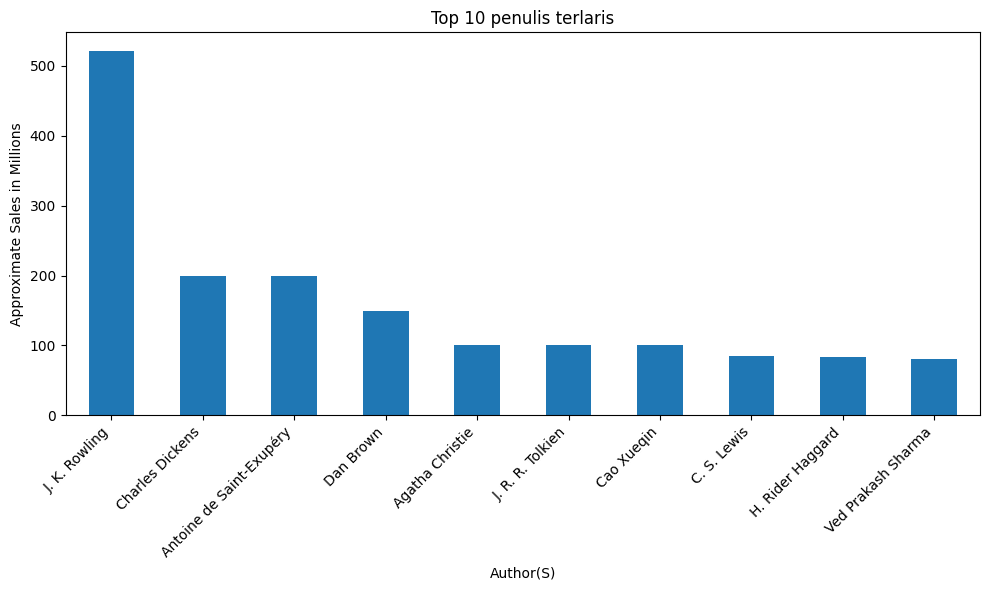

In [76]:
penulis_buku_terlaris = (df_buku.groupby("Author(s)")["Approximate sales in millions"].sum()).sort_values(ascending=False).head(10)
# print(penulis_buku_terlaris.head())

plt.figure(figsize=(10, 6))
penulis_buku_terlaris.plot(kind='bar')
plt.title('Top 10 penulis terlaris')
plt.xlabel('Author(S)')
plt.ylabel('Approximate Sales in Millions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


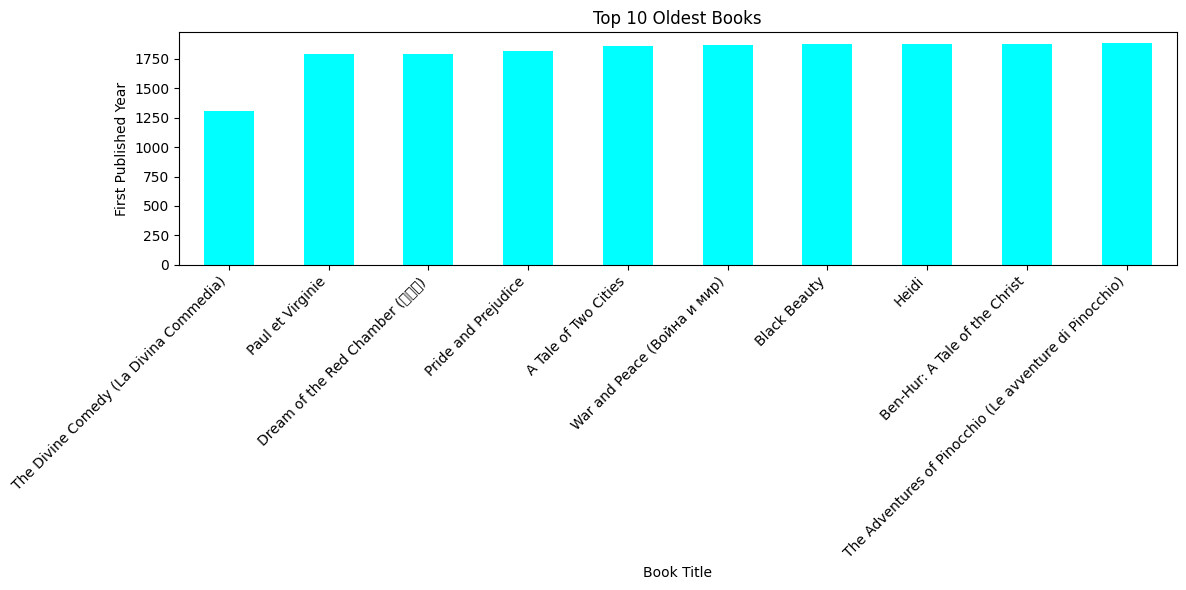

In [77]:
buku_tertua_df = df_buku.sort_values(by="First published", ascending=True).head(10)

nama_buku_tertua = (buku_tertua_df.set_index('Book')['First published']).sort_values(ascending = True).head(10)

plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Noto Sans CJK JP', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 6))
nama_buku_tertua.plot(kind = "bar", color = "cyan")
plt.title('Top 10 buku tertua')
plt.xlabel('Judul buku')
plt.ylabel('Tahun terbit pertama kali')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

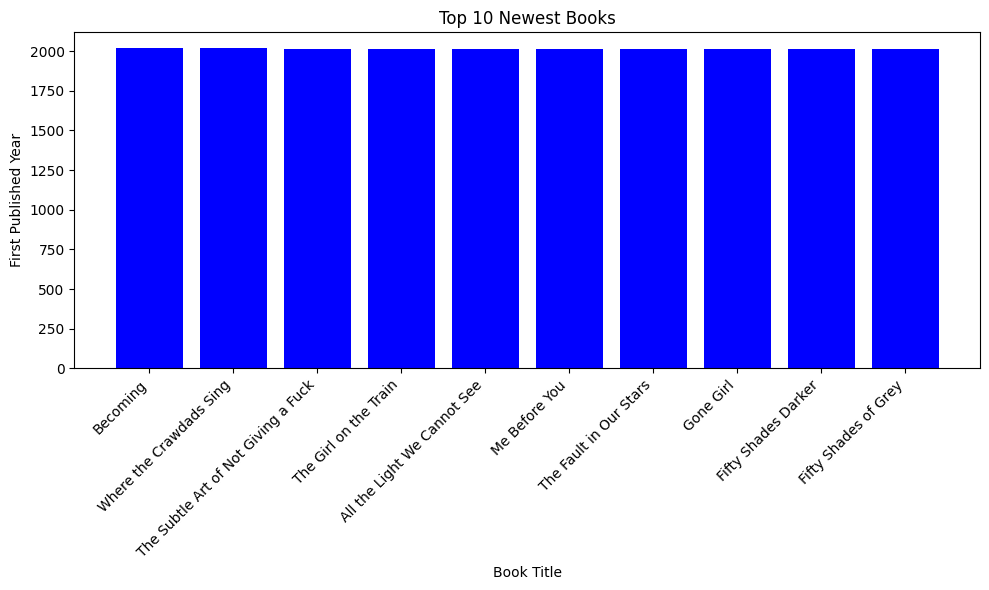

In [78]:
df_buku = pd.read_excel("data_buku.xlsx")

buku_terbaru = df_buku.sort_values(by='First published', ascending=False).head(10)
# print(buku_terbaru[['Book', 'First published']])

plt.figure(figsize=(10, 6))
plt.bar(buku_terbaru['Book'], buku_terbaru['First published'], color = "blue")
plt.title('Top 10 buku terbaru')
plt.xlabel('Judul buku')
plt.ylabel('Tahun terbit pertama kali')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

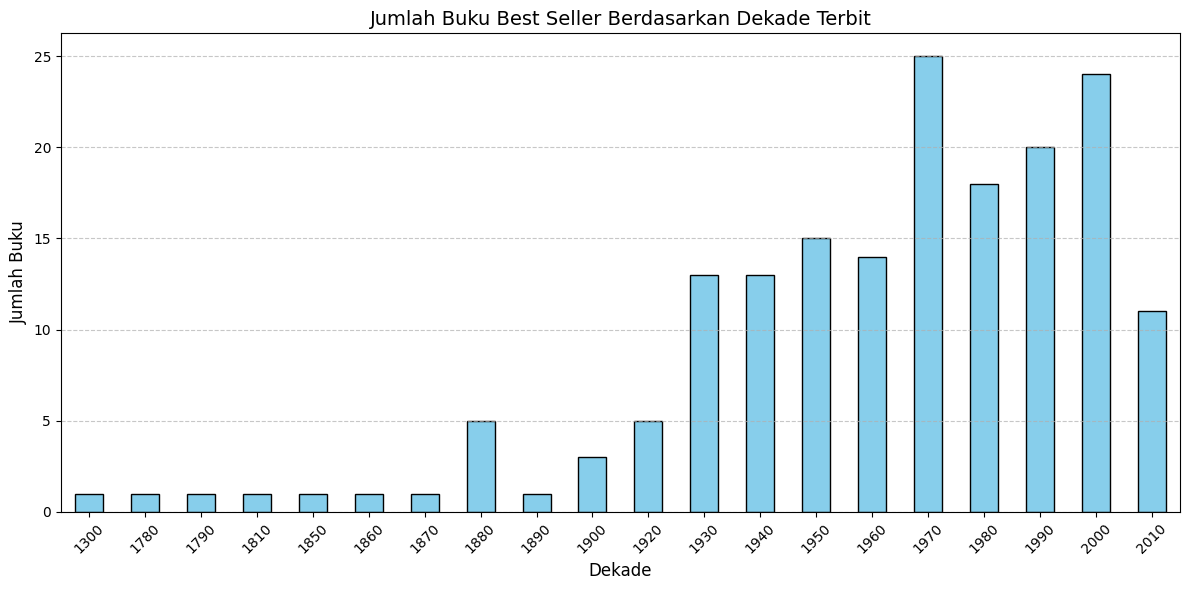

In [79]:
df = pd.read_excel("data_buku.xlsx")

df['First published'] = pd.to_numeric(df['First published'], errors='coerce')

df = df.dropna(subset=['First published'])

df['Decade'] = (df['First published'] // 10) * 10

dekade_jumlah = df['Decade'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
dekade_jumlah.plot(kind='bar', color='skyblue', edgecolor='black', ax=plt.gca())
plt.title('Jumlah Buku Best Seller Berdasarkan Dekade Terbit', fontsize=14)
plt.xlabel('Dekade', fontsize=12)
plt.ylabel('Jumlah Buku', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

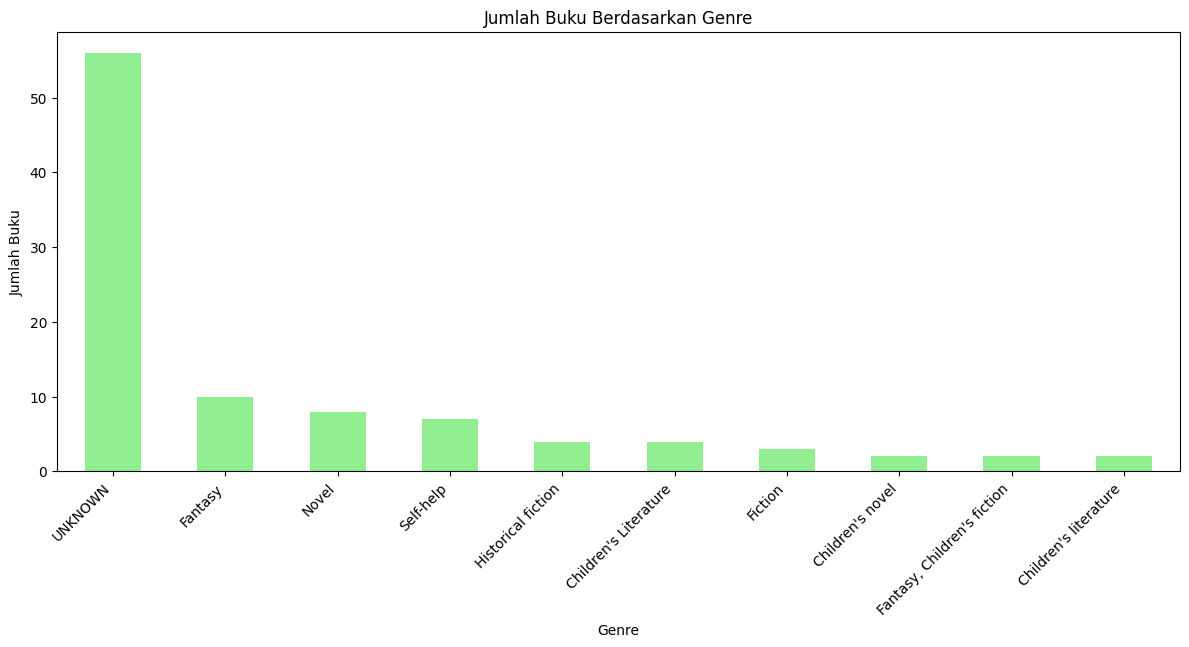

In [80]:
jumlah_buku_berdasar_genre = df_buku["Genre"].value_counts(ascending = False).head(10)
# print(jumlah_buku_berdasar_genre.head())

plt.figure(figsize=(12, 7))
jumlah_buku_berdasar_genre.plot(kind='bar', color='lightgreen')
plt.title('Jumlah Buku Berdasarkan Genre')
plt.xlabel('Genre')
plt.ylabel('Jumlah Buku')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

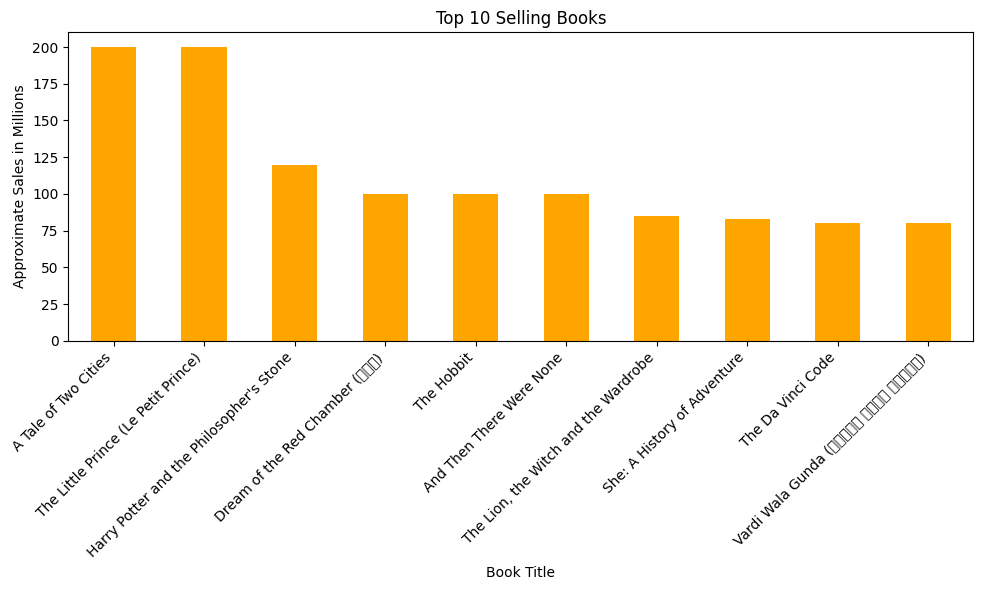

In [81]:
penjualan_tertinggi = (df_buku.groupby("Book")["Approximate sales in millions"].sum()).sort_values(ascending=False).head(10)
# print(penjualan_tertinggi.head(10))

plt.figure(figsize=(10, 6))
penjualan_tertinggi.plot(kind='bar', color='orange')
plt.title('Top 10 buku terlari')
plt.xlabel('Judul buku')
plt.ylabel('Perkiraan penjualan dalam jutaan')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

DARI TABEL YANG TELAH DISAJIKAN. DAPAT DIAMBIL KESIMPULAN BAHWA, BUKU BUKU YANG MEMILIKI GENRE FANTASY LALU DIIKUTI NOVEL, MEMILIKI TINGKAT POPULARITAS LEBIH TINGGI DIBANDINGKAN DENGAN BUKU BUKU DENGAN GENRE LAINNYA


DENGAN HASIL ANALISA, KITA DAPAT MENGAMBIL KESIMPULAN BAHWA GENRE FANTASY MEMILIKI TINGKAT KEPOPULERAN YANG LEBIH TINGGI DIBANDINGKAN GENRE LAINNYA DAN MEMILIKI KEMUNGKINAN TERTINGGI UNTUK MENDAPATKAN POTENSI PENERBITAN LEBIH TINGGI.

BUKU KLASIK MASIH DAPAT MENGAMBIL KESEMPATAN UNTUK MENDAPATKAN KEPOPULERANNYA. NAMUN, PERLU DI INGAT BAHWA KITA HARUS MENENTUKAN GENRE YANG DI INGINKAN UNTUK DAPAT BERSAING DENGAN BUKU BUKU LAINNYA.

BERDASARKAN DATA, PENULIS YANG MENDOMINASI PASAR ADALAH J.K ROWLING

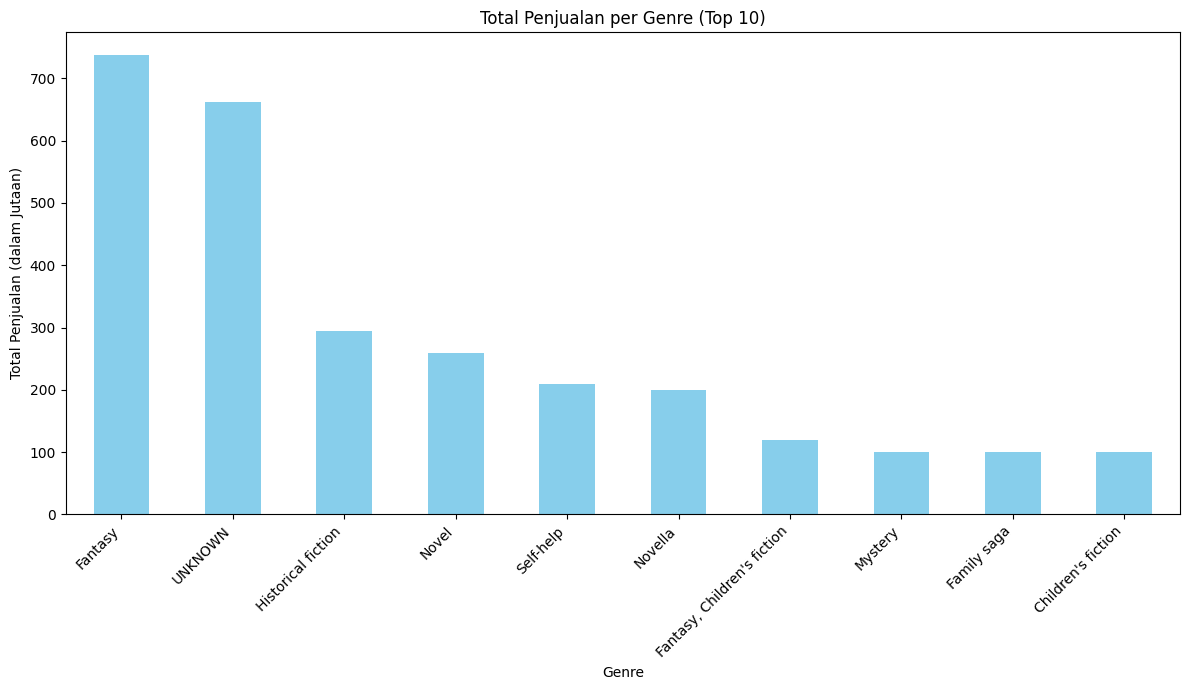

In [82]:
penjualan_per_genre = df_buku.groupby('Genre')['Approximate sales in millions'].sum().sort_values(ascending=False)
# display(penjualan_per_genre)

plt.figure(figsize=(12, 7))
penjualan_per_genre.head(10).plot(kind='bar', color='skyblue')
plt.title('Total Penjualan per Genre (Top 10)')
plt.xlabel('Genre')
plt.ylabel('Total Penjualan (dalam Jutaan)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

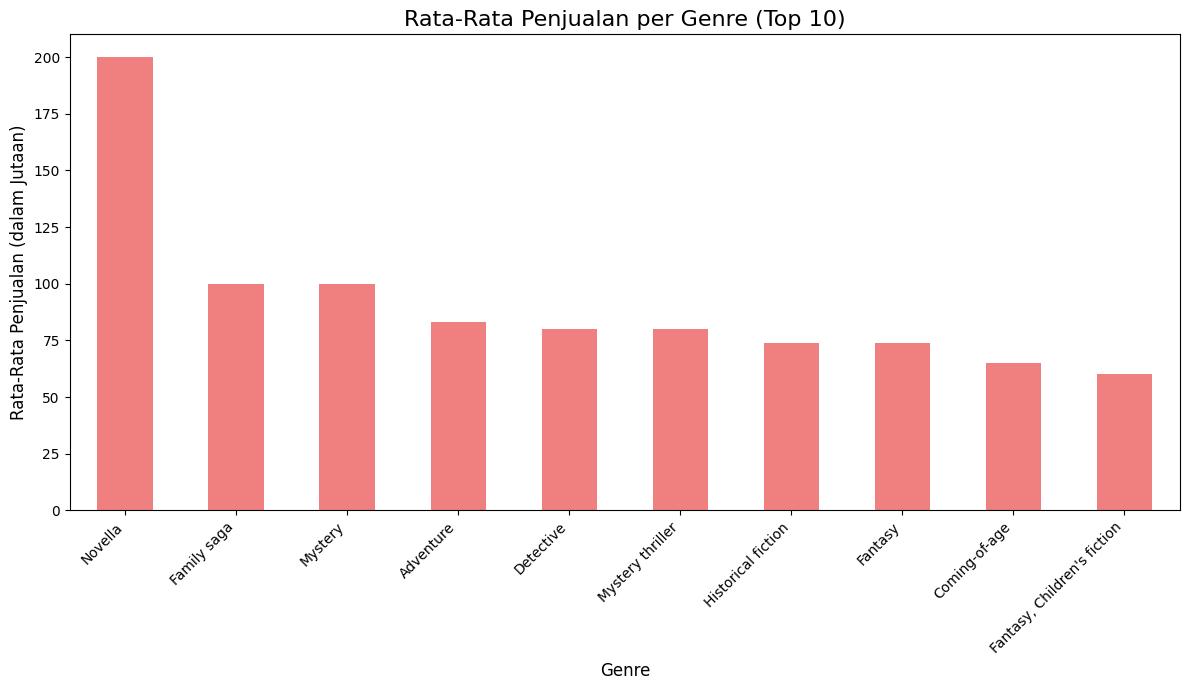

In [83]:
rata_rata_penjualan_per_genre = df_buku.groupby('Genre')['Approximate sales in millions'].mean().sort_values(ascending=False)
# display(rata_rata_penjualan_per_genre)

plt.figure(figsize=(12, 7))
rata_rata_penjualan_per_genre.head(10).plot(kind='bar', color='lightcoral')
plt.title('Rata-Rata Penjualan per Genre (Top 10)', fontsize=16)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Rata-Rata Penjualan (dalam Jutaan)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [84]:
df_top_total_sales = penjualan_per_genre.head(10).reset_index()
df_top_total_sales.columns = ['Genre', 'Total Sales']
print("Top 10 genres by total sales:")
print(df_top_total_sales.head())

Top 10 genres by total sales:
                Genre  Total Sales
0             Fantasy        737.0
1             UNKNOWN        662.6
2  Historical fiction        295.0
3               Novel        259.5
4           Self-help        210.0


In [85]:
df_top_avg_sales = rata_rata_penjualan_per_genre.head(10).reset_index()
df_top_avg_sales.columns = ['Genre', 'Average Sales']
print("Top 10 genres by average sales:")
print(df_top_avg_sales.head())

Top 10 genres by average sales:
         Genre  Average Sales
0      Novella          200.0
1  Family saga          100.0
2      Mystery          100.0
3    Adventure           83.0
4    Detective           80.0


In [86]:
df_combined_sales = pd.merge(df_top_total_sales, df_top_avg_sales, on='Genre', how='outer')
print("Combined DataFrame (head):")
print(df_combined_sales.head())
print("\nCombined DataFrame (tail):")
print(df_combined_sales.tail())

Combined DataFrame (head):
                Genre  Total Sales  Average Sales
0           Adventure          NaN           83.0
1  Children's fiction        100.0            NaN
2       Coming-of-age          NaN           65.0
3           Detective          NaN           80.0
4         Family saga        100.0          100.0

Combined DataFrame (tail):
               Genre  Total Sales  Average Sales
9   Mystery thriller          NaN           80.0
10             Novel        259.5            NaN
11           Novella        200.0          200.0
12         Self-help        210.0            NaN
13           UNKNOWN        662.6            NaN


In [87]:
df_combined_sales.fillna(0, inplace=True)
print("Combined DataFrame after filling NaN (head):")
print(df_combined_sales.head())
print("\nCombined DataFrame after filling NaN (tail):")
print(df_combined_sales.tail())

Combined DataFrame after filling NaN (head):
                Genre  Total Sales  Average Sales
0           Adventure          0.0           83.0
1  Children's fiction        100.0            0.0
2       Coming-of-age          0.0           65.0
3           Detective          0.0           80.0
4         Family saga        100.0          100.0

Combined DataFrame after filling NaN (tail):
               Genre  Total Sales  Average Sales
9   Mystery thriller          0.0           80.0
10             Novel        259.5            0.0
11           Novella        200.0          200.0
12         Self-help        210.0            0.0
13           UNKNOWN        662.6            0.0


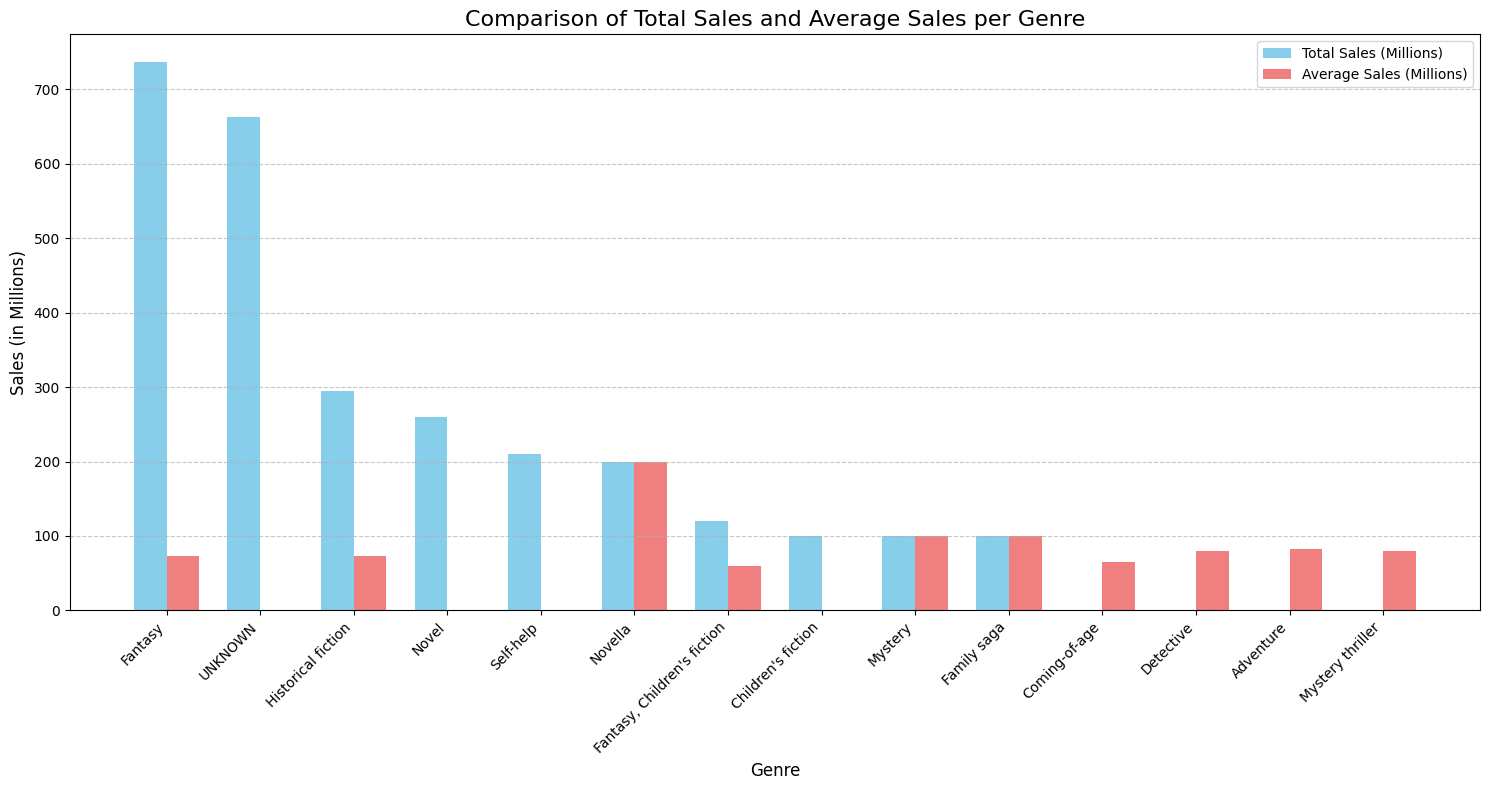

In [88]:
# Sort the combined DataFrame by Total Sales (descending) for better visualization
df_combined_sales_sorted = df_combined_sales.sort_values(by='Total Sales', ascending=False).reset_index(drop=True)

# Set the positions for the bars on the x-axis
x = np.arange(len(df_combined_sales_sorted['Genre']))
width = 0.35 # Width of the bars

plt.figure(figsize=(15, 8))

# Plotting Total Sales
plt.bar(x - width/2, df_combined_sales_sorted['Total Sales'], width, label='Total Sales (Millions)', color='skyblue')

# Plotting Average Sales
plt.bar(x + width/2, df_combined_sales_sorted['Average Sales'], width, label='Average Sales (Millions)', color='lightcoral')

# Add labels, title, and legend
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Sales (in Millions)', fontsize=12)
plt.title('Comparison of Total Sales and Average Sales per Genre', fontsize=16)
plt.xticks(x, df_combined_sales_sorted['Genre'], rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()